In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv('salaries.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           133349 non-null  int64 
 1   experience_level    133349 non-null  object
 2   employment_type     133349 non-null  object
 3   job_title           133349 non-null  object
 4   salary              133349 non-null  int64 
 5   salary_currency     133349 non-null  object
 6   salary_in_usd       133349 non-null  int64 
 7   employee_residence  133349 non-null  object
 8   remote_ratio        133349 non-null  int64 
 9   company_location    133349 non-null  object
 10  company_size        133349 non-null  object
dtypes: int64(4), object(7)
memory usage: 11.2+ MB


### ver quanto a pessoa resebe em dolares de acordo com as qualidades
- Tirar o ano

### ver qual e o emprego da pessoa baseado nas coisas ai

In [6]:
df.drop(columns=['salary','salary_currency'],inplace=True)

# Correlacion:

In [34]:
correlacion = np.corrcoef(df['work_year'], df['salary_in_usd'])
correlacion

array([[1.        , 0.01960043],
       [0.01960043, 1.        ]])

In [35]:
correlacion = np.corrcoef(df['salary_in_usd'], df['remote_ratio'])
correlacion

array([[ 1.        , -0.04813117],
       [-0.04813117,  1.        ]])

# Year:

In [36]:
year_work = df[['work_year','salary_in_usd']].groupby('work_year').median().round(2)
year_work

,salary_in_usd
work_year,
2020,79833.0
2021,83872.0
2022,131300.0
2023,145000.0
2024,148947.0
2025,145000.0


#### How many peeplo working by the year:

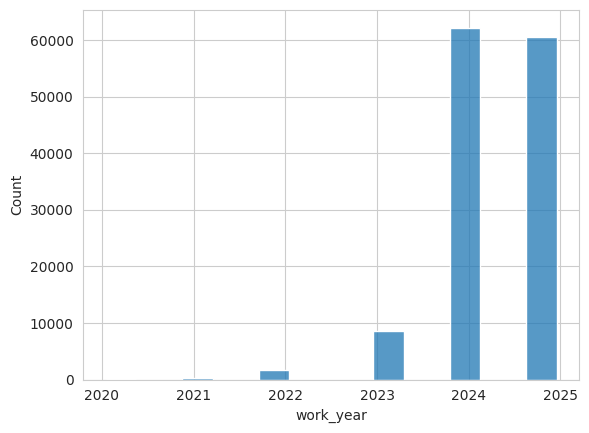

In [37]:
with sns.axes_style('whitegrid'):
    grafico = sns.histplot(data = df , x = 'work_year', multiple = 'dodge', shrink = 0.8,binwidth=0.4)   

#### Year by the remote ratio:

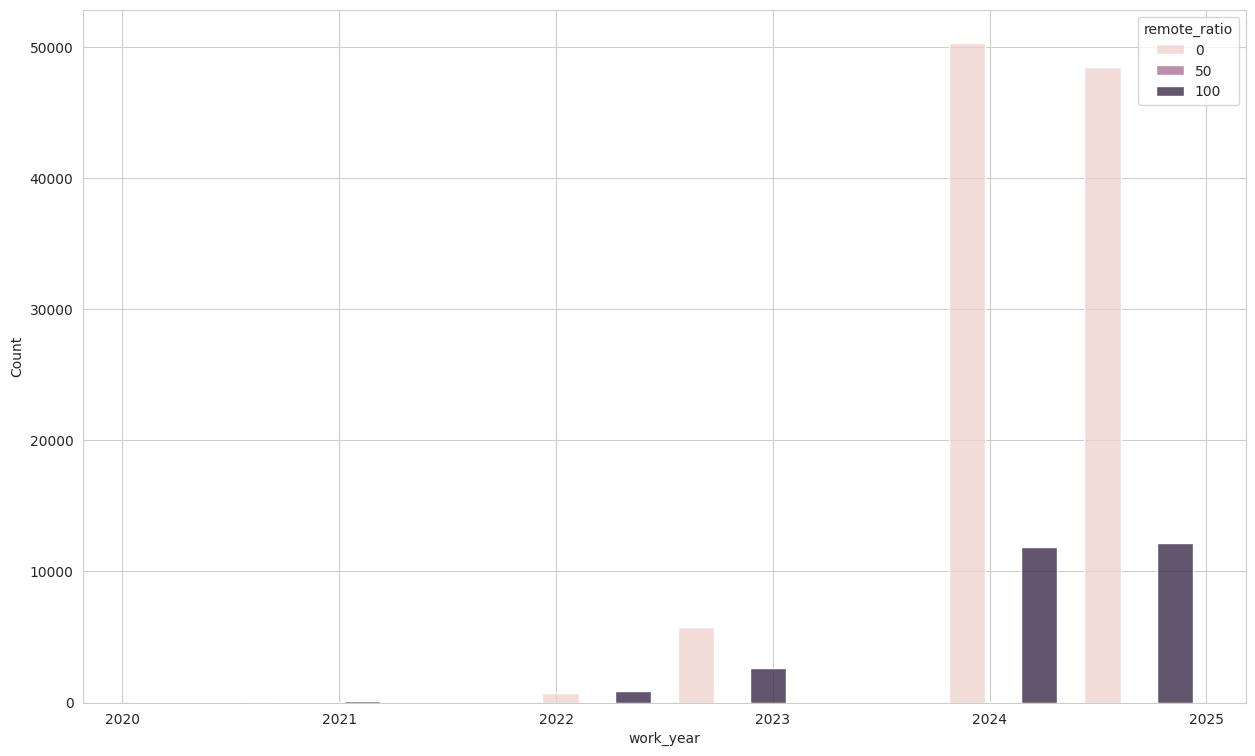

In [38]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (15,9))
    grafico = sns.histplot(data = df, x = 'work_year',hue = 'remote_ratio', multiple = 'dodge',shrink = 0.8,binwidth=0.6)
    

#### Year by employment type:

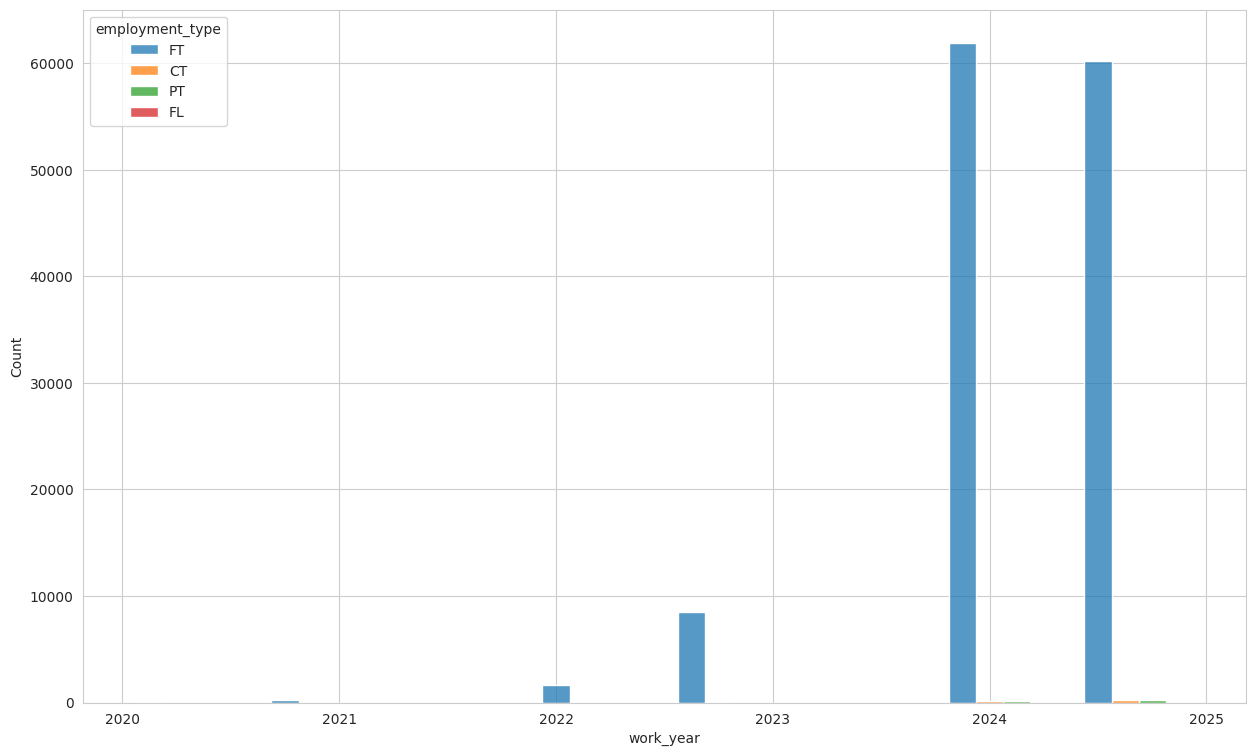

In [39]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (15,9))
    grafico = sns.histplot(data = df, x = 'work_year',hue = 'employment_type', multiple = 'dodge',shrink = 0.8,binwidth=0.6)

# Year by company size:

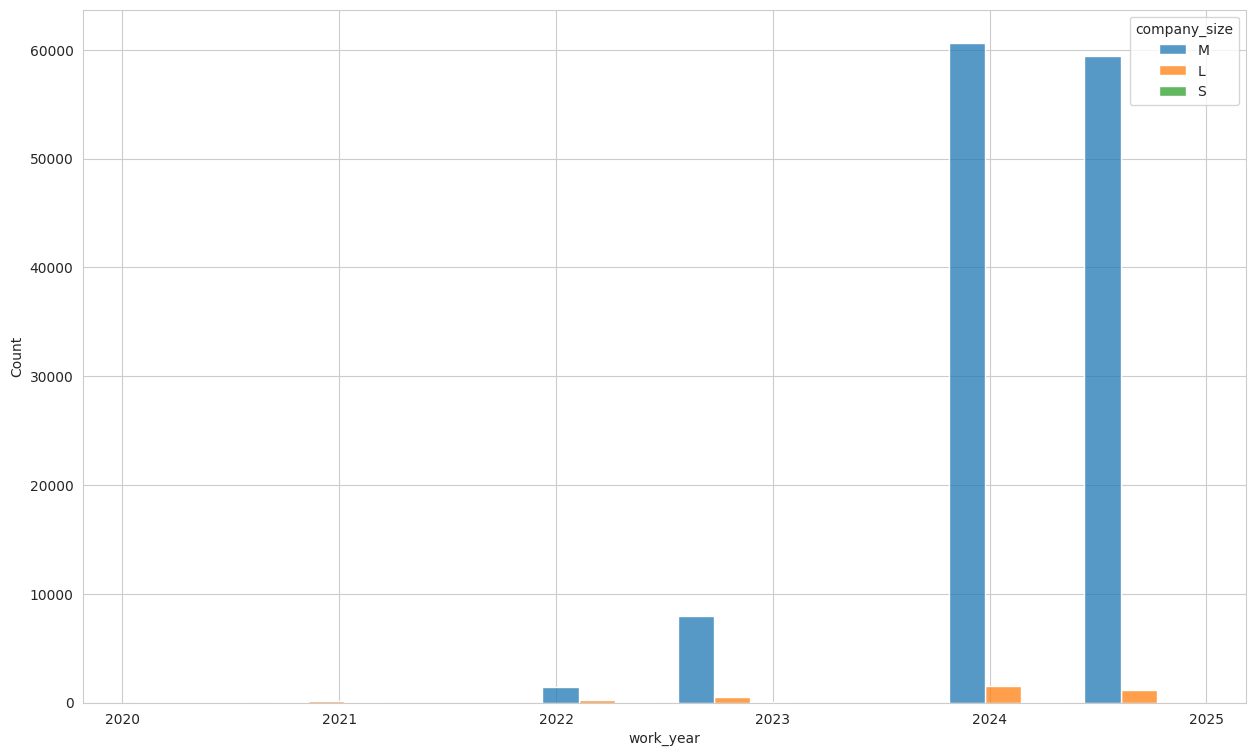

In [40]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (15,9))
    grafico = sns.histplot(data = df, x = 'work_year',hue = 'company_size', multiple = 'dodge',shrink = 0.8,binwidth=0.6)

# experience level:

#### how many experience level we have:

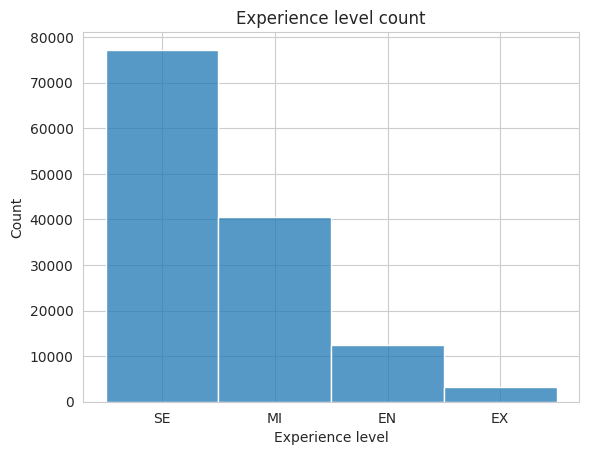

In [41]:
with sns.axes_style('whitegrid'):
    grafico = sns.histplot(data = df, x = 'experience_level')
    grafico.set(title = 'Experience level count', xlabel = 'Experience level', ylabel = 'Count')

#### Experience level by the employment type

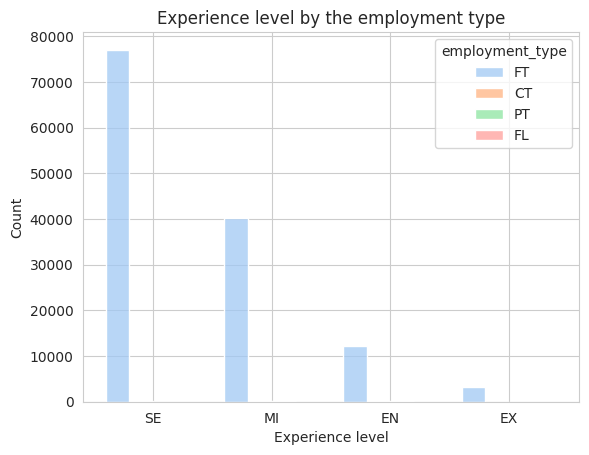

In [42]:
with sns.axes_style('whitegrid'):
    grafico = sns.histplot(data = df, x = 'experience_level', hue = 'employment_type', multiple = 'dodge',shrink = 0.8, palette = 'pastel')
    grafico.set(title = 'Experience level by the employment type', xlabel = 'Experience level', ylabel = 'Count')

#### Experience level by the salary in USD

In [43]:
a = df['experience_level'].value_counts()
a

experience_level
SE    77241
MI    40465
EN    12443
EX     3200
Name: count, dtype: int64

In [44]:
teste = df[['salary_in_usd','experience_level']].groupby('experience_level').median().reset_index().round(2)
teste

,experience_level,salary_in_usd
0,EN,86551.0
1,EX,190000.0
2,MI,130000.0
3,SE,161154.0


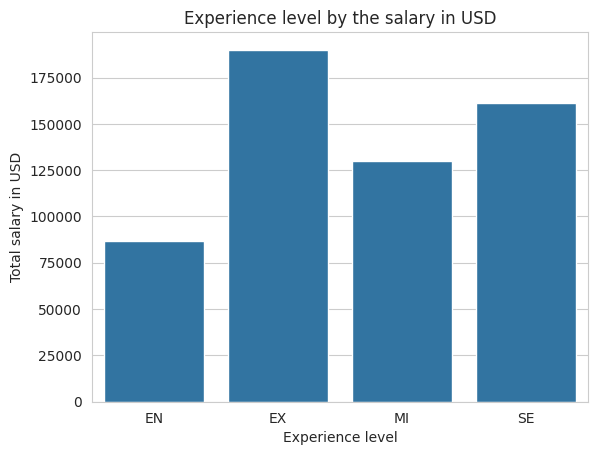

In [45]:
with sns.axes_style('whitegrid'):
    grafico = sns.barplot(data = teste, x = 'experience_level', y = 'salary_in_usd')
    grafico.set(title ='Experience level by the salary in USD', xlabel = 'Experience level', ylabel = 'Total salary in USD')

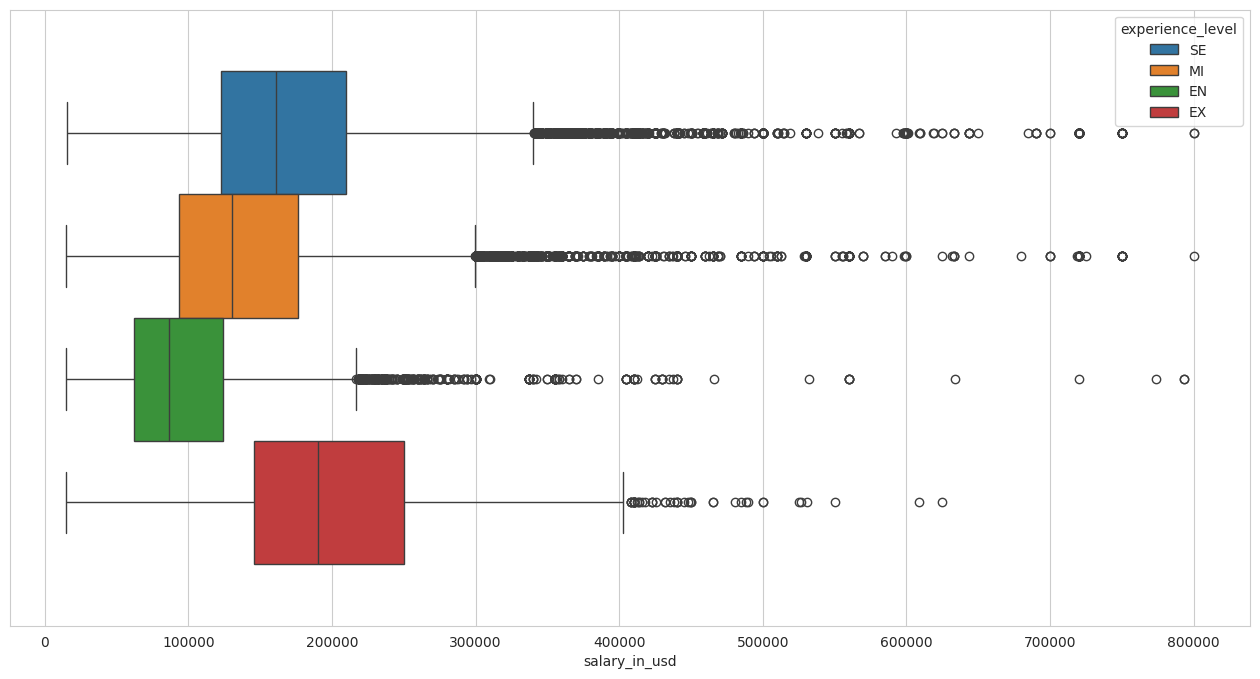

In [46]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(16, 8)) 
    grafico = sns.boxplot(data=df, x='salary_in_usd', hue='experience_level')

#### Employment type by remote radio:

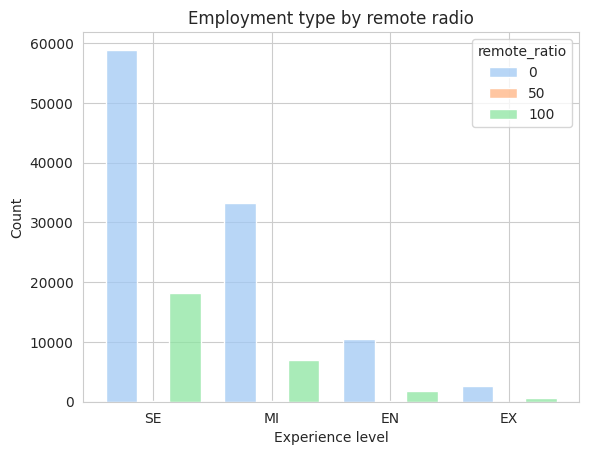

In [47]:
with sns.axes_style('whitegrid'):
    grafico = sns.histplot(data = df , x = 'experience_level', hue = 'remote_ratio', multiple = 'dodge', shrink = 0.8, palette = 'pastel')
    grafico.set(title = 'Employment type by remote radio', xlabel = 'Experience level', ylabel = 'Count')

#### Employment type by company size:

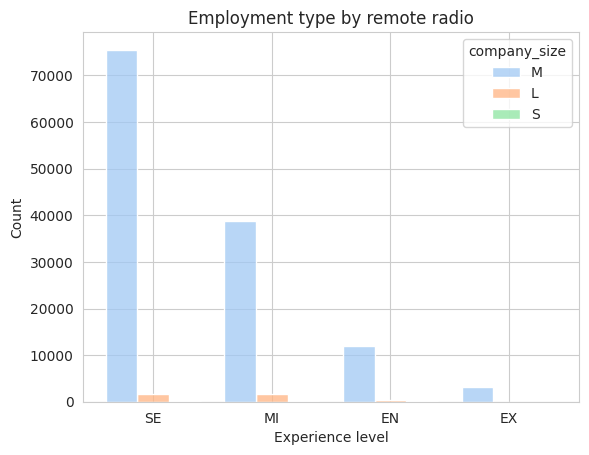

In [48]:
with sns.axes_style('whitegrid'):
    grafico = sns.histplot(data = df , x = 'experience_level', hue = 'company_size', multiple = 'dodge', shrink = 0.8, palette = 'pastel')
    grafico.set(title = 'Employment type by remote radio', xlabel = 'Experience level', ylabel = 'Count')

# Employment type

#### Employment count:

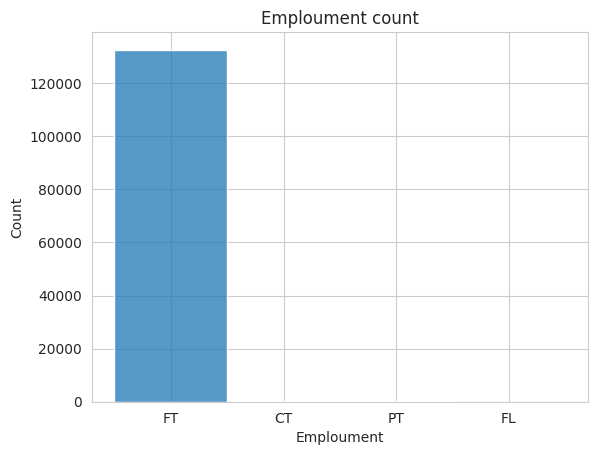

In [49]:
with sns.axes_style('whitegrid'):
    grafico = sns.histplot(data = df , x = 'employment_type')
    grafico.set(title = 'Emploument count', xlabel = 'Emploument', ylabel = 'Count')

#### Employment type by the salary in USD:

In [50]:
group = df[['employment_type','salary_in_usd']].groupby('employment_type').median().reset_index().round(2)
group

,employment_type,salary_in_usd
0,CT,100000.0
1,FL,50000.0
2,FT,147000.0
3,PT,60000.0


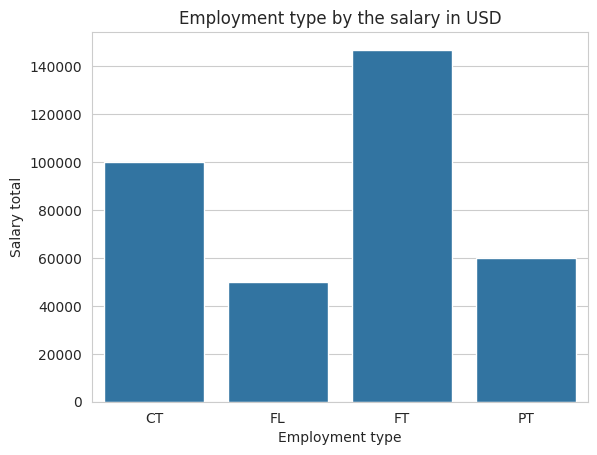

In [51]:
with sns.axes_style('whitegrid'):
    grafico = sns.barplot(data = group, x = 'employment_type', y = 'salary_in_usd')
    grafico.set(title = 'Employment type by the salary in USD', xlabel = 'Employment type', ylabel = 'Salary total')

#### employment type remote ratio:

In [52]:
remont_count = df[['employment_type','remote_ratio']].groupby('employment_type').value_counts().reset_index()
remont_count

,employment_type,remote_ratio,count
0,CT,0,214
1,CT,100,177
2,CT,50,3
3,FL,100,10
4,FL,0,3
5,FL,50,3
6,FT,0,104802
7,FT,100,27457
8,FT,50,304
9,PT,0,293


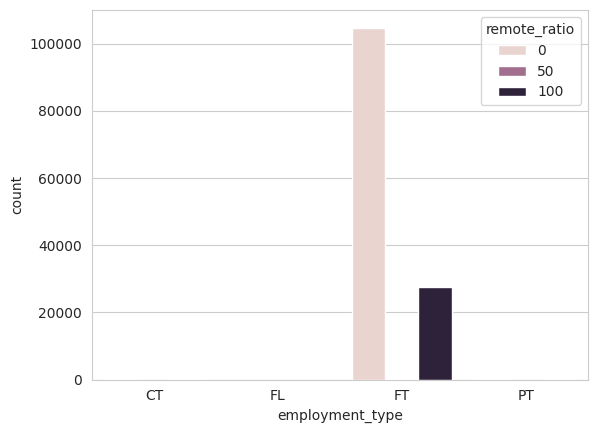

In [53]:
with sns.axes_style('whitegrid'):
    grafico = sns.barplot(data = remont_count , x = 'employment_type', y = 'count', hue = 'remote_ratio')


#### Employment type by the  count of company size:
	

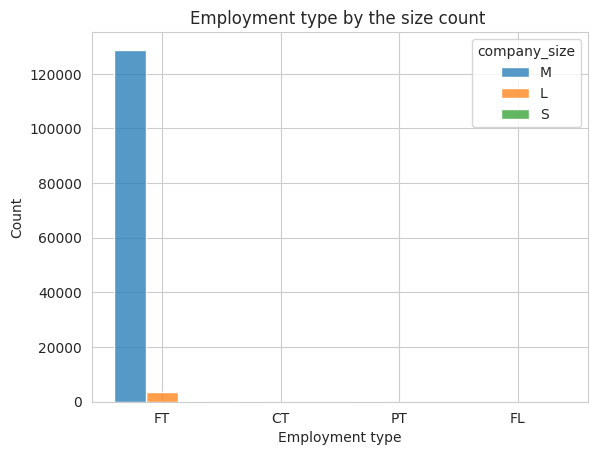

In [54]:
with sns.axes_style('whitegrid'):
    grafico = sns.histplot(data = df , x = 'employment_type', hue = 'company_size', multiple = 'dodge', shrink = 0.8)
    grafico.set(title = 'Employment type by the size count ', xlabel = 'Employment type', ylabel = 'Count')

# JOB :

#### Counts many jobs:

In [55]:
counts_job = df['job_title'].value_counts().reset_index()
counts_job.query('count > 200', inplace= True)
counts_job

,job_title,count
0,Data Scientist,17314
1,Software Engineer,15007
2,Data Engineer,14868
3,Data Analyst,12381
4,Engineer,9456
5,Machine Learning Engineer,8205
6,Manager,6679
7,Analyst,4364
8,Research Scientist,3202
9,Product Manager,2230


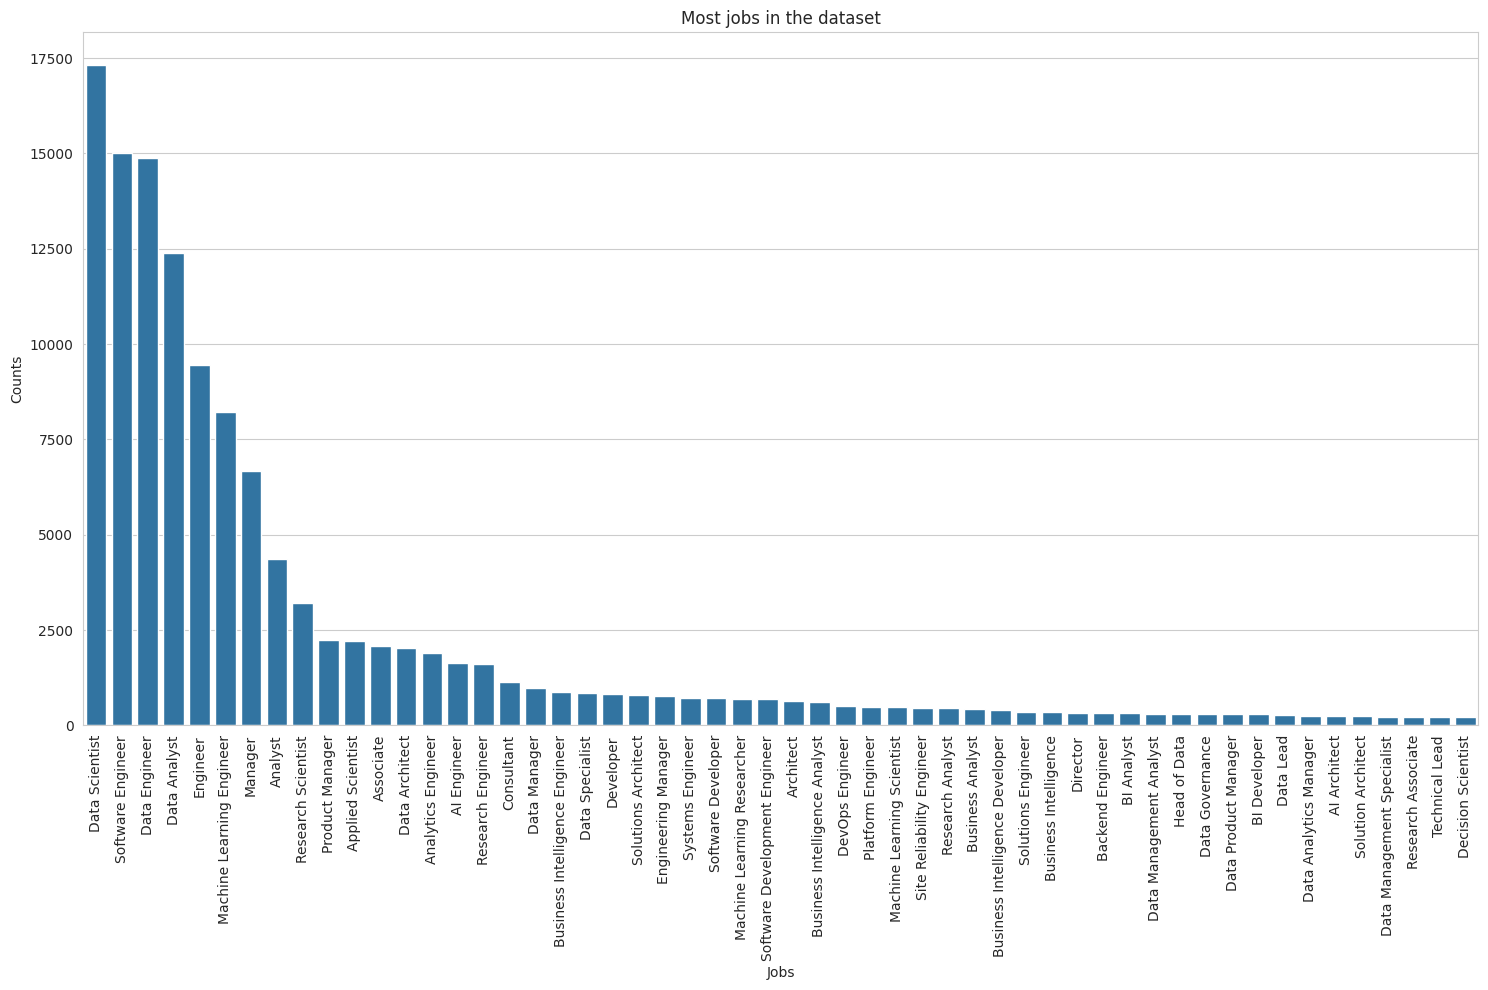

In [56]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (18,9))
    grafico = sns.barplot(data = counts_job, x = 'job_title', y = 'count')
    grafico.set(title = 'Most jobs in the dataset', xlabel = 'Jobs', ylabel = 'Counts')
    plt.xticks(rotation = 90)

#### Jobs by the salary:

In [57]:
job = df[['job_title','salary_in_usd']].groupby('job_title').median().round(2)
job.sort_values(by = 'salary_in_usd', ascending = True, inplace = False)
reduce_job = job.head(53).reset_index()
reduce_job

,job_title,salary_in_usd
0,AI Architect,195000.0
1,AI Content Writer,43680.0
2,AI Data Engineer,94444.0
3,AI Data Scientist,60000.0
4,AI Developer,141400.0
5,AI Engineer,165577.5
6,AI Engineering Lead,23649.0
7,AI Engineering Manager,179930.5
8,AI Governance Lead,126582.0
9,AI Governance Specialist,106087.5


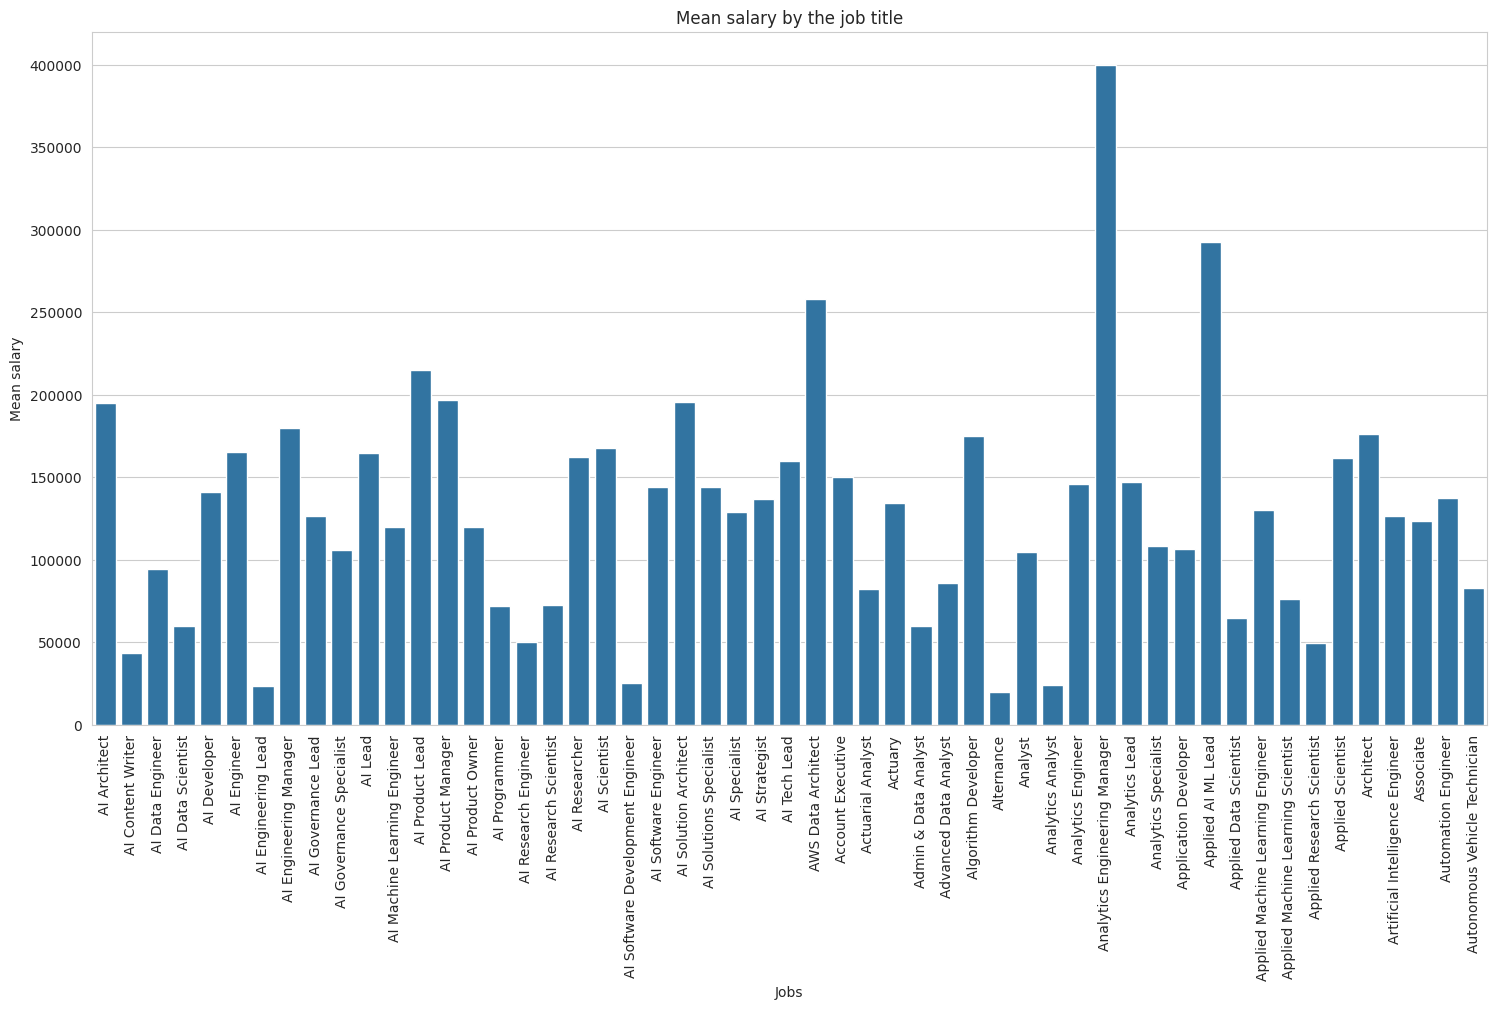

In [58]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (18,9))
    grafico = sns.barplot(data = reduce_job, x = 'job_title', y = 'salary_in_usd')
    grafico.set(title = 'Mean salary by the job title', xlabel = 'Jobs', ylabel = 'Mean salary')
    plt.xticks(rotation = 90)


#### job by the remote ratio:

In [59]:
job_remote = df[['job_title','remote_ratio']].groupby('remote_ratio').value_counts().reset_index()
job_50 = job_remote.query('remote_ratio == 50 and count > 1')

job_100 = job_remote.query('remote_ratio == 100 and count > 100')

job_0 = job_remote.query('remote_ratio == 0 and count > 200 ')



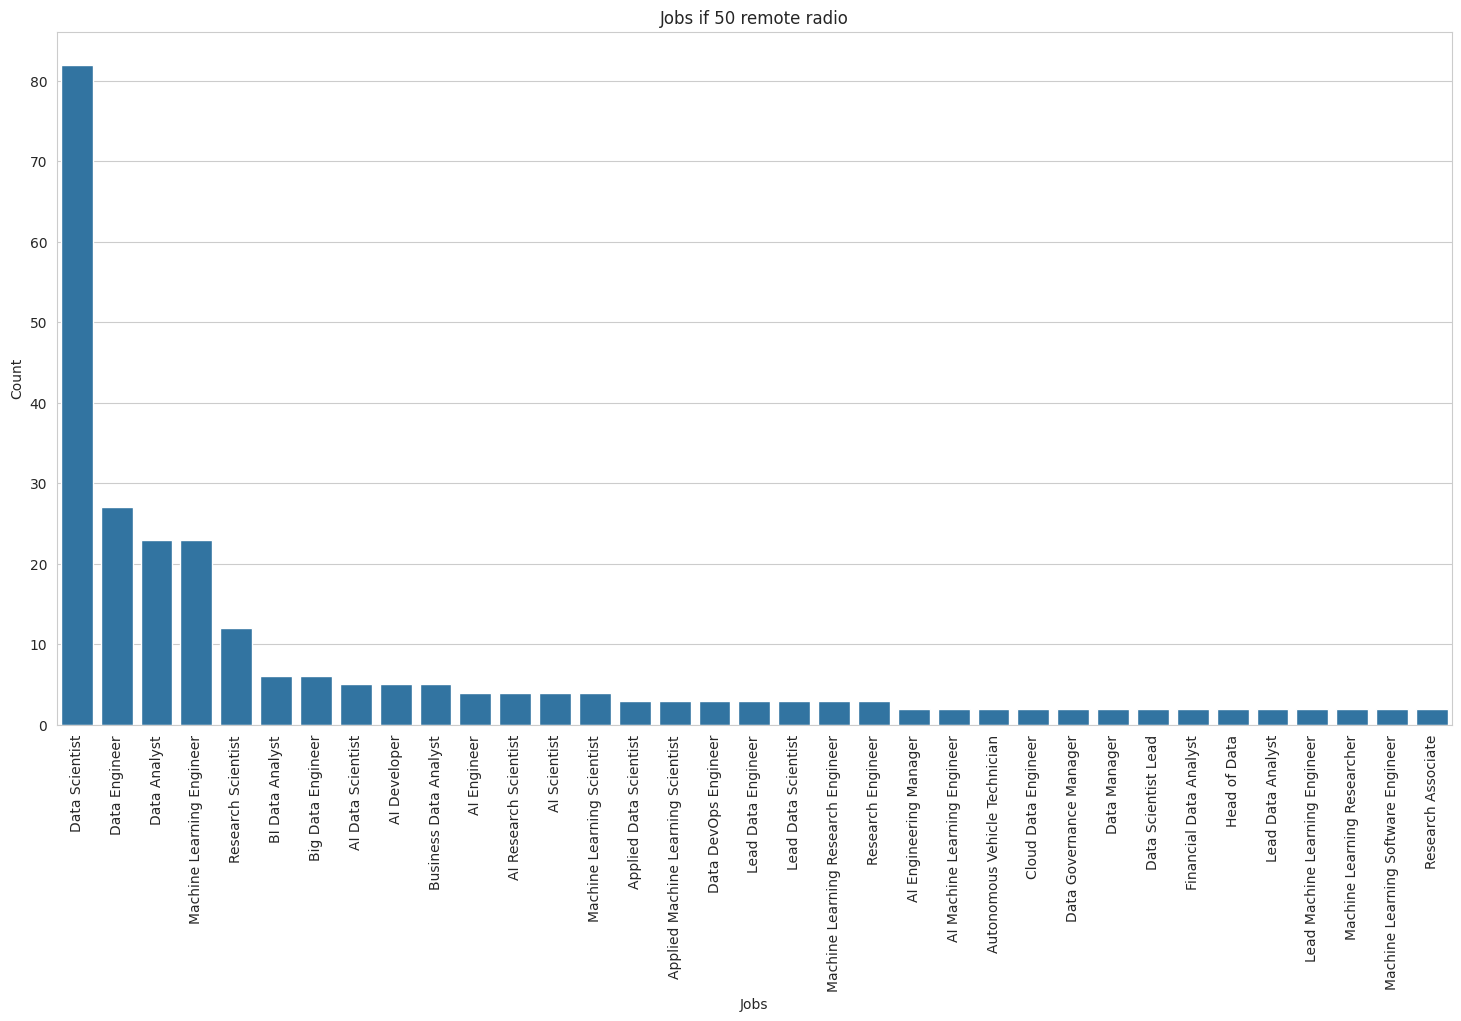

In [60]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (18,9))
    grafico = sns.barplot(data = job_50, x = 'job_title', y = 'count')
    grafico.set(title = 'Jobs if 50 remote radio', xlabel = 'Jobs', ylabel = 'Count')
    plt.xticks(rotation = 90)


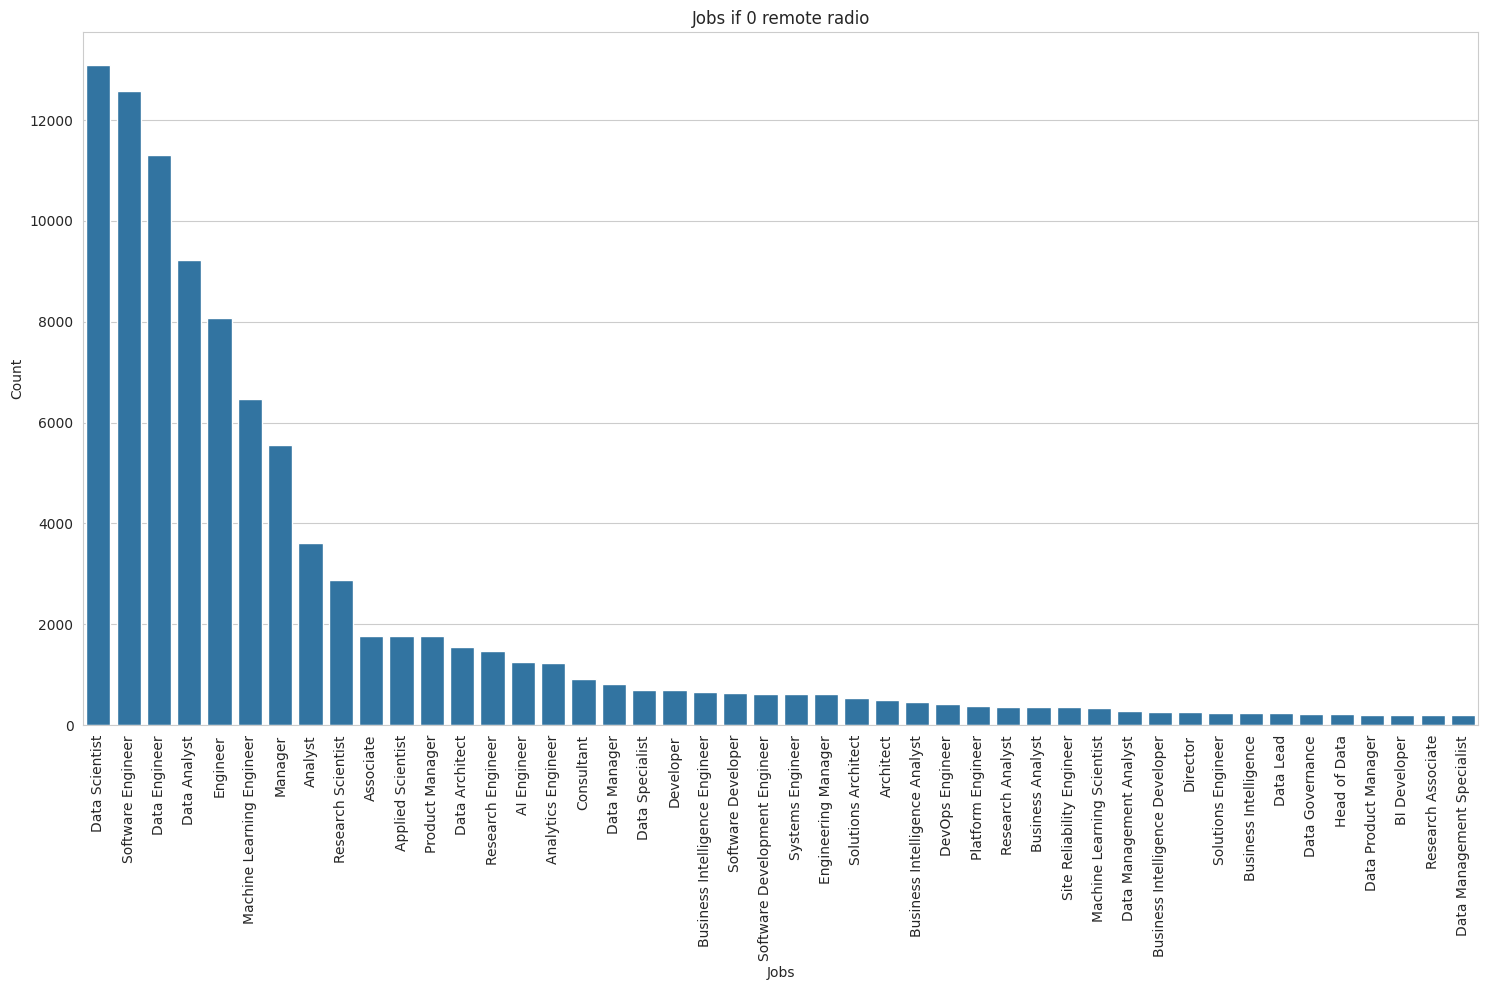

In [61]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (18,9))
    grafico = sns.barplot(data = job_0, x = 'job_title', y = 'count')
    grafico.set(title = 'Jobs if 0 remote radio', xlabel = 'Jobs', ylabel = 'Count')
    plt.xticks(rotation = 90)

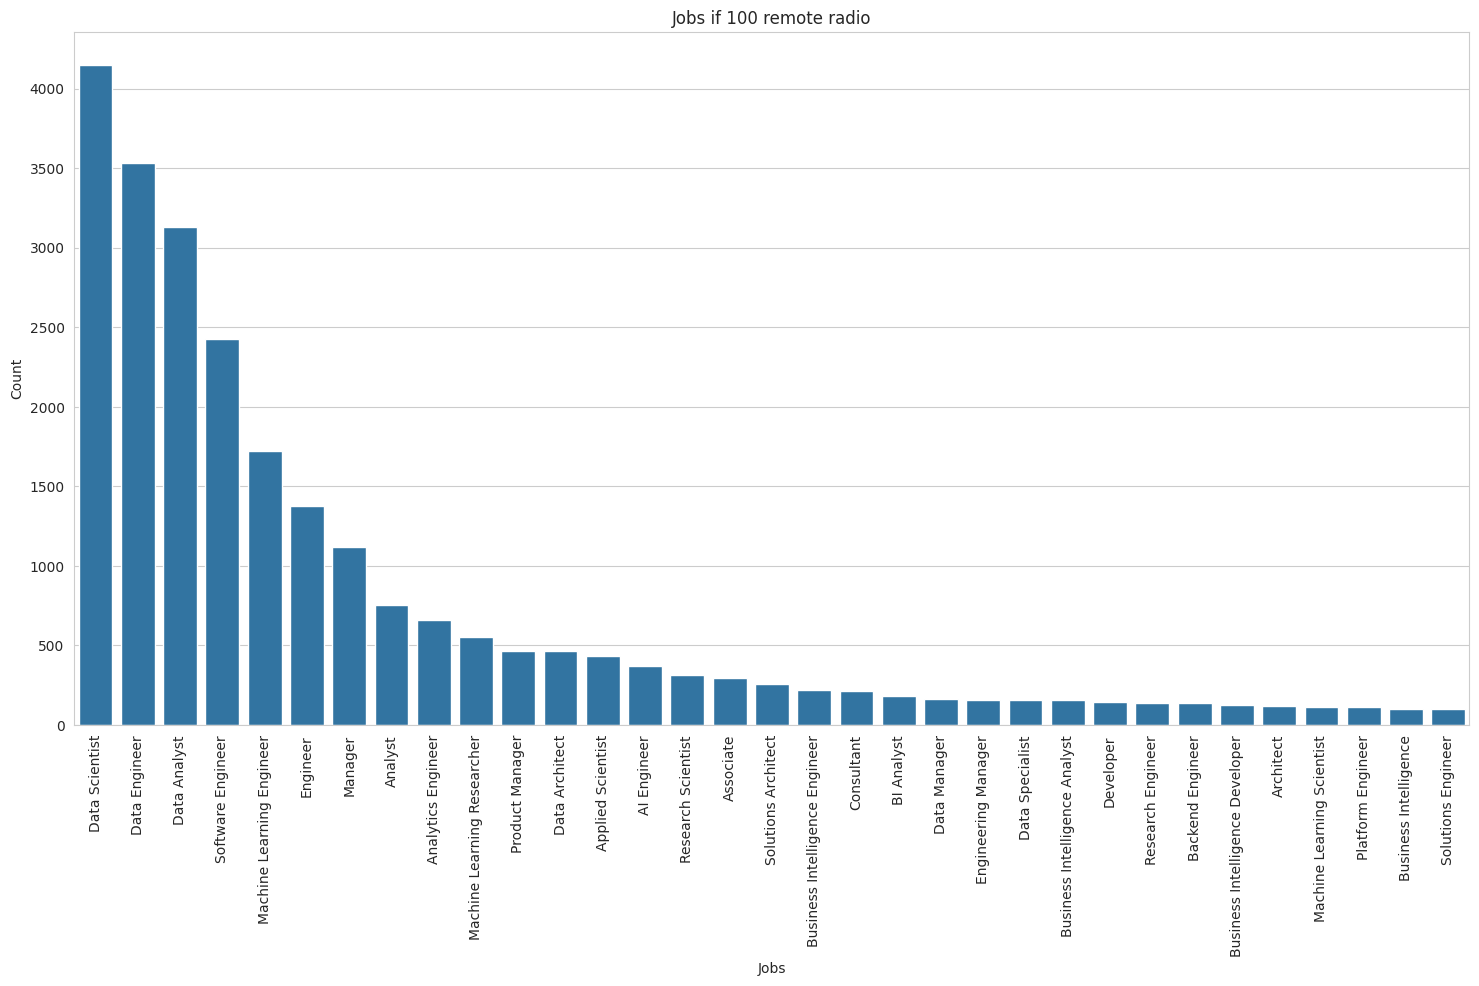

In [62]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (18,9))
    grafico = sns.barplot(data = job_100, x = 'job_title', y = 'count')
    grafico.set(title = 'Jobs if 100 remote radio', xlabel = 'Jobs', ylabel = 'Count')
    plt.xticks(rotation = 90)

In [63]:
counts_location = df['company_location'].value_counts()
counts_location = counts_location[counts_location > 1000]
df_filtre = df[df['company_location'].isin(counts_location.index)]
df_filtre

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,SE,FT,Solutions Engineer,214000,US,100,US,M
1,2025,SE,FT,Solutions Engineer,136000,US,100,US,M
4,2025,EN,FT,Data Engineer,90000,US,0,US,M
5,2025,EN,FT,Data Engineer,80000,US,0,US,M
6,2025,SE,FT,Data Scientist,185000,US,0,US,M
...,...,...,...,...,...,...,...,...,...
133343,2021,SE,FT,Data Specialist,165000,US,100,US,L
133344,2020,SE,FT,Data Scientist,412000,US,100,US,L
133345,2021,MI,FT,Principal Data Scientist,151000,US,100,US,L
133346,2020,EN,FT,Data Scientist,105000,US,100,US,S


# Salary in usd:

#### Salart by the company:

In [64]:
salary_by_company = df[['company_location','salary_in_usd']].groupby('company_location').median().round(2).sort_values(by = 'salary_in_usd', ascending = False ).reset_index()


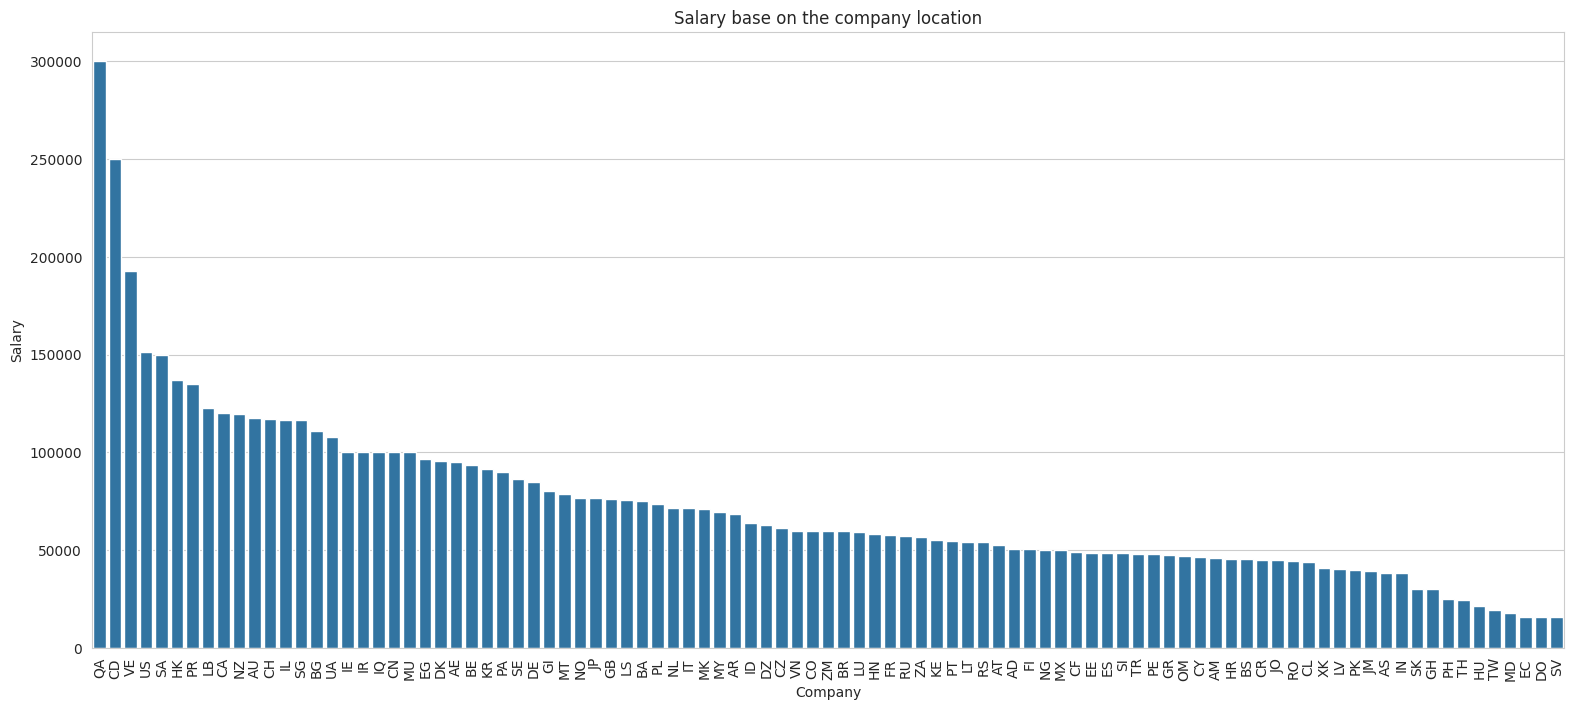

In [65]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (19,8))
    grafico = sns.barplot(data = salary_by_company , x = 'company_location', y = 'salary_in_usd')
    grafico.set(title = 'Salary base on the company location', xlabel = 'Company', ylabel = 'Salary')
    plt.xticks(rotation = 90)

#### Salary if the company and the employer are in the diferent countrys:

In [66]:
division_diference= df.query('employee_residence != company_location')
division_igual = df.query('employee_residence == company_location')
df_new = division_diference[division_diference['job_title'].isin(division_igual['job_title'])]
df_new.reset_index(drop = True)
df_new[df_new['job_title'].duplicated()].reset_index(drop =True)

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,MI,FT,AI Data Scientist,34000,IN,100,US,L
1,2024,SE,FT,AI Data Scientist,166666,CH,100,IT,M
2,2024,SE,CT,AI Engineer,120000,PL,100,US,S
3,2024,EN,FT,Machine Learning Engineer,88888,LU,50,DE,L
4,2024,EN,FT,AI Data Scientist,30012,IN,50,AU,M
...,...,...,...,...,...,...,...,...,...
94,2020,SE,FL,Computer Vision Engineer,60000,RU,100,US,S
95,2021,EN,FT,AI Scientist,18053,IN,100,AS,S
96,2020,MI,FT,Data Scientist,62726,FR,50,LU,S
97,2020,MI,FT,Data Engineer,130800,ES,100,US,M


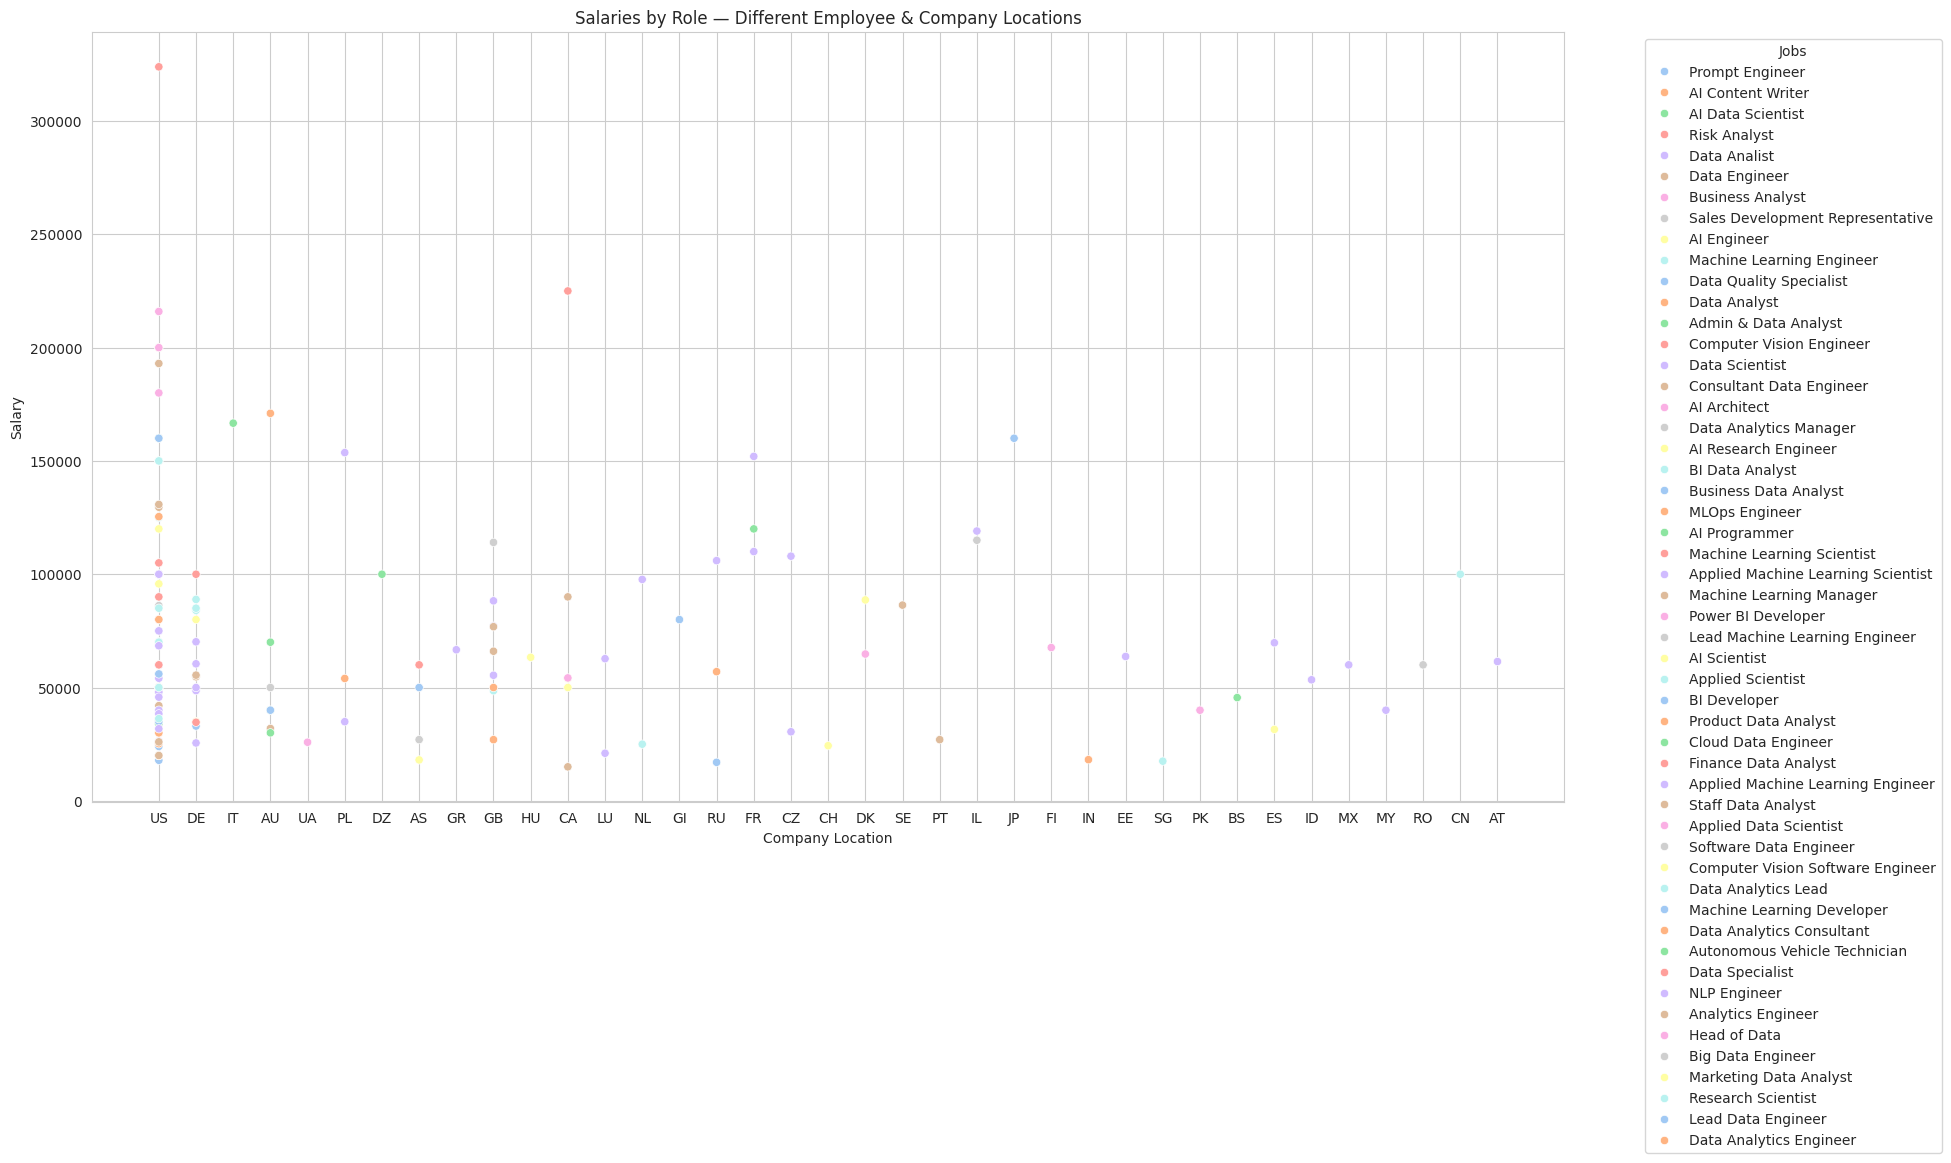

In [67]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (19,10))
    grafico = sns.scatterplot(data = df_new , x = 'company_location', y = 'salary_in_usd',hue = 'job_title',palette = 'pastel')
    grafico.set(title = 'Salaries by Role — Different Employee & Company Locations', xlabel = 'Company Location', ylabel = 'Salary')
    plt.legend(title='Jobs', bbox_to_anchor=(1.05, 1), loc='upper left')
   

#### Salary if the company and the employer are in the same countrys:

In [68]:
df_new_icol = division_igual[division_igual['job_title'].isin(df['job_title'])]
df_new_icol.reset_index(drop = True)
df_new_icol[df_new_icol['job_title'].duplicated()].reset_index(drop =True)

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,SE,FT,Solutions Engineer,136000,US,100,US,M
1,2025,MI,FT,Data Engineer,139200,AU,0,AU,M
2,2025,EN,FT,Data Engineer,90000,US,0,US,M
3,2025,EN,FT,Data Engineer,80000,US,0,US,M
4,2025,SE,FT,Data Scientist,148000,US,0,US,M
...,...,...,...,...,...,...,...,...,...
132802,2020,SE,FT,Data Scientist,412000,US,100,US,L
132803,2021,MI,FT,Principal Data Scientist,151000,US,100,US,L
132804,2020,EN,FT,Data Scientist,105000,US,100,US,S
132805,2020,EN,CT,Business Data Analyst,100000,US,100,US,L


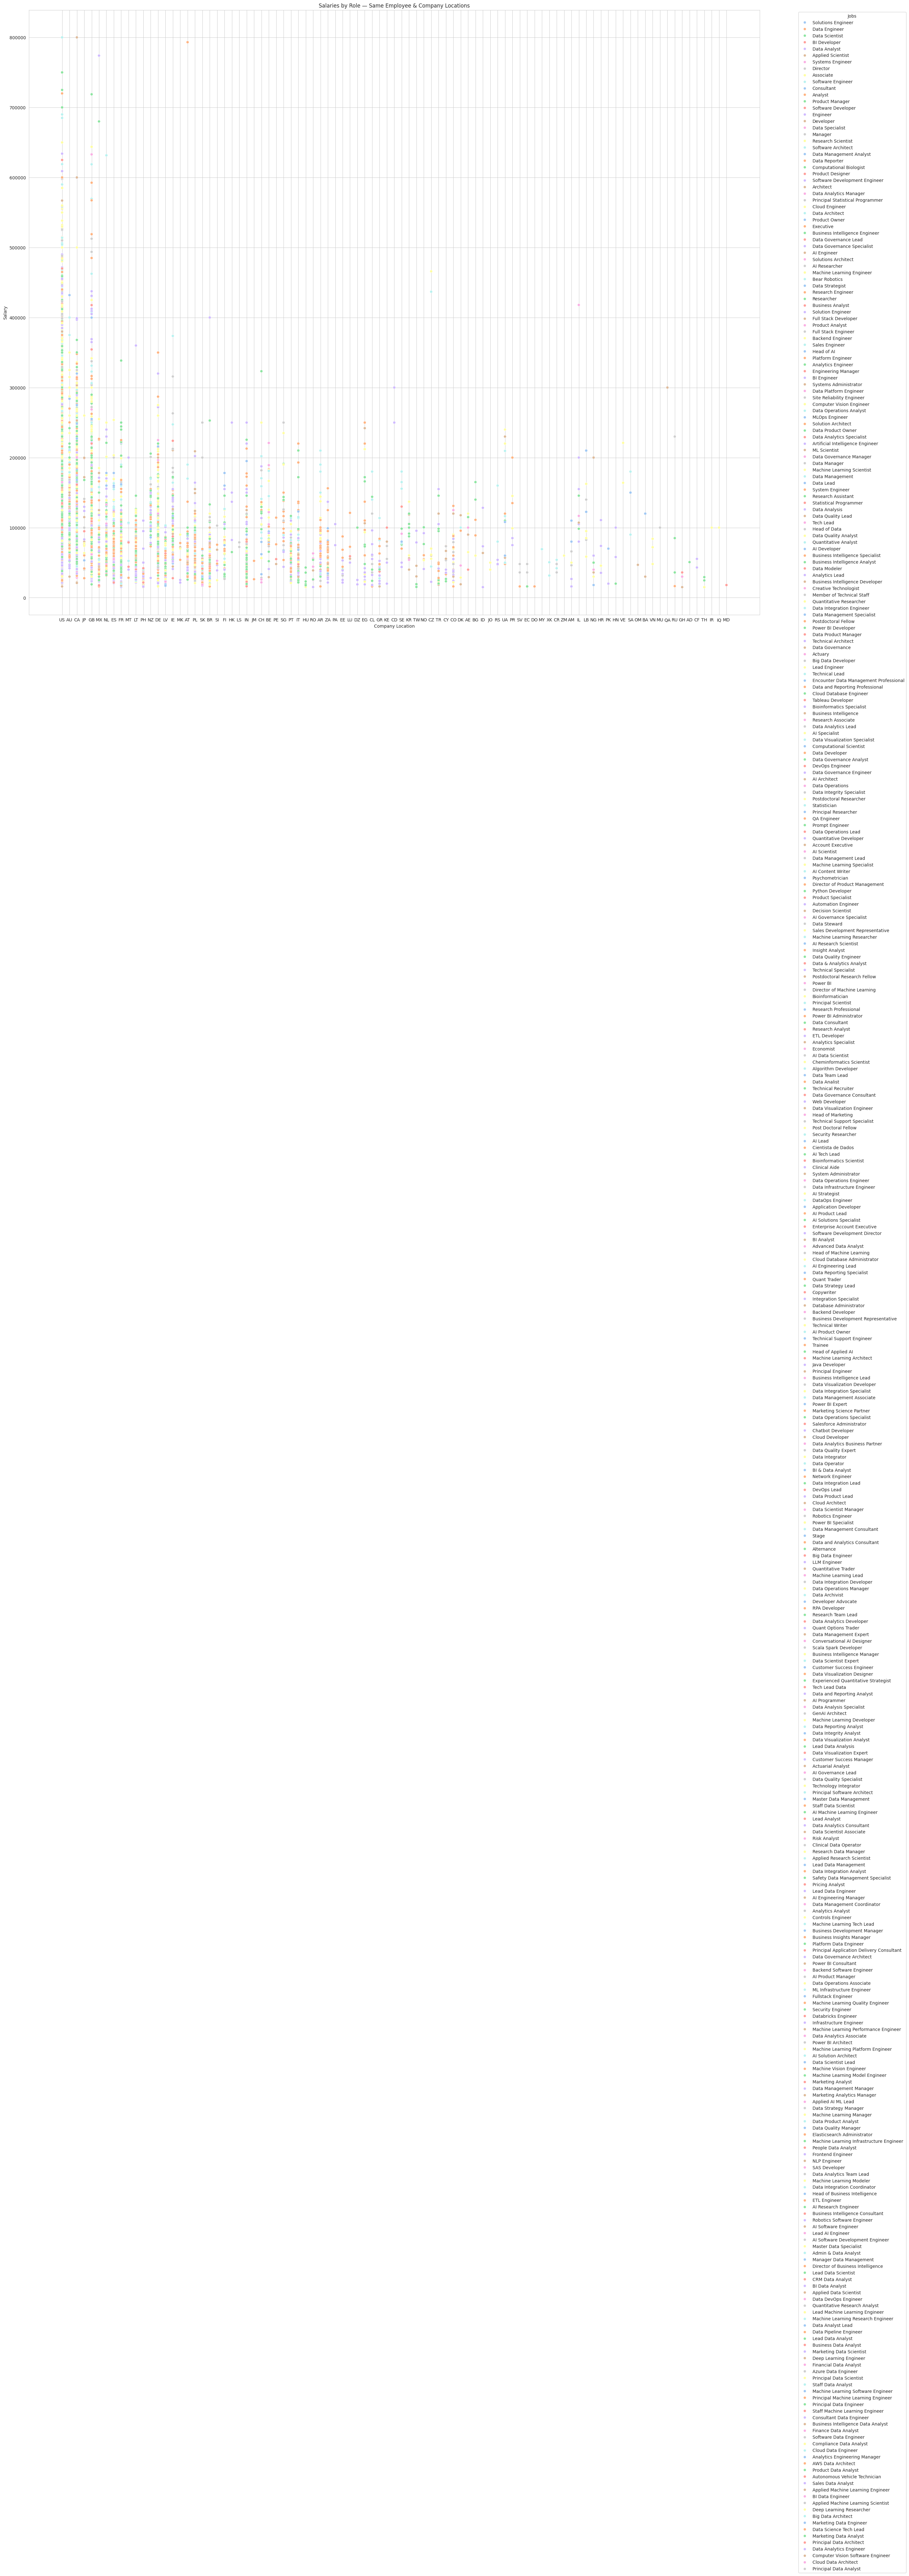

In [69]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (30,25))
    grafico = sns.scatterplot(data = df_new_icol , x = 'company_location', y = 'salary_in_usd',hue = 'job_title',palette = 'pastel')
    grafico.set(title = 'Salaries by Role — Same Employee & Company Locations', xlabel = 'Company Location', ylabel = 'Salary')
    plt.legend(title='Jobs', bbox_to_anchor=(1.05, 1), loc='upper left')

#### Salary by the remote ratio:

In [70]:
remont_salary = df[['salary_in_usd','remote_ratio']].groupby('remote_ratio').median().reset_index().round(2)
remont_salary

,remote_ratio,salary_in_usd
0,0,147300.0
1,50,67419.0
2,100,145000.0


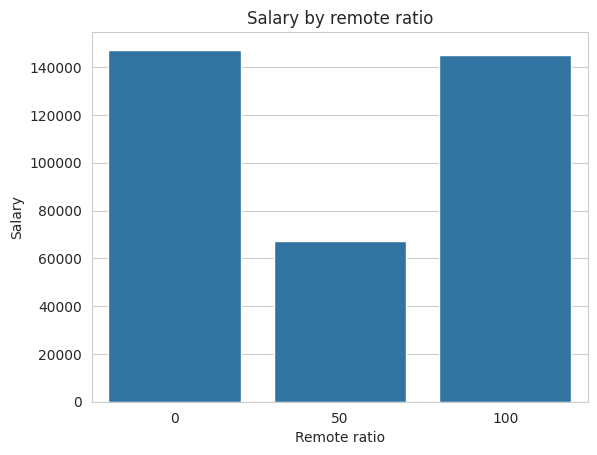

In [71]:
with sns.axes_style('whitegrid'):
    grafico = sns.barplot(data = remont_salary, x = 'remote_ratio', y = 'salary_in_usd')
    grafico.set(title = 'Salary by remote ratio', xlabel = 'Remote ratio', ylabel = 'Salary')

# Categoric :

In [72]:
df

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,SE,FT,Solutions Engineer,214000,US,100,US,M
1,2025,SE,FT,Solutions Engineer,136000,US,100,US,M
2,2025,MI,FT,Data Engineer,158800,AU,0,AU,M
3,2025,MI,FT,Data Engineer,139200,AU,0,AU,M
4,2025,EN,FT,Data Engineer,90000,US,0,US,M
...,...,...,...,...,...,...,...,...,...
133344,2020,SE,FT,Data Scientist,412000,US,100,US,L
133345,2021,MI,FT,Principal Data Scientist,151000,US,100,US,L
133346,2020,EN,FT,Data Scientist,105000,US,100,US,S
133347,2020,EN,CT,Business Data Analyst,100000,US,100,US,L


In [73]:
df['experience_level'].unique()

array(['SE', 'MI', 'EN', 'EX'], dtype=object)

In [7]:
dict_experienc = {'EN': 1,
                  'MI': 2,
                  'SE': 3,
                  'EX' : 4}

In [8]:
categoric_df = df.copy()

In [9]:
categoric_df['experience_level_nunbers'] = categoric_df['experience_level'].apply(lambda x : dict_experienc[x])


In [10]:
df['employment_type'].unique()

array(['FT', 'CT', 'PT', 'FL'], dtype=object)

In [11]:
categoric_df['employment_type_FT'] = categoric_df['employment_type'].apply(lambda x : 1 if x == 'FT' else 0)
categoric_df['employment_type_CT'] = categoric_df['employment_type'].apply(lambda x : 1 if x == 'CT' else 0)
categoric_df['employment_type_PT'] = categoric_df['employment_type'].apply(lambda x : 1 if x == 'PT' else 0)
categoric_df['employment_type_FL'] = categoric_df['employment_type'].apply(lambda x : 1 if x == 'FL' else 0)

In [12]:
m_salary = categoric_df['salary_in_usd'].mean()
std_salary = categoric_df['salary_in_usd'].std()

categoric_df['salary_in_usd_std'] = categoric_df['salary_in_usd'].apply(lambda x : (x - m_salary) / std_salary)

In [13]:
count = categoric_df['employee_residence'].value_counts()
filtro = count[count > 30].index

categoric_df = categoric_df[categoric_df['employee_residence'].isin(filtro)]

In [81]:
categoric_df['employee_residence'].unique()

array(['US', 'AU', 'CA', 'JP', 'GB', 'MX', 'NL', 'ES', 'FR', 'IT', 'LT',
       'PH', 'NZ', 'DE', 'LV', 'IE', 'AT', 'PL', 'SK', 'BR', 'FI', 'IN',
       'CH', 'SG', 'PT', 'AR', 'ZA', 'EG', 'CO'], dtype=object)

In [82]:
categoric_df['North_America'] = categoric_df ['employee_residence'].apply(lambda x : 1 if x in ['US','CA','MX'] else 0)
categoric_df['Latin_America'] = categoric_df ['employee_residence'].apply(lambda x : 1 if x in ['BR','AR','CO'] else 0)
categoric_df['Europe'] = categoric_df['employee_residence'].apply(lambda x : 1 if x in ['GB','NL','ES','FR','IT','LT','LV','IE','AT','PL','SK','FI','DE','PT','CH'] else 0)
categoric_df['Asia'] = categoric_df ['employee_residence'].apply(lambda x : 1 if x in ['JP','PH','IN','SG','EG'] else 0)
categoric_df['Oceania'] = categoric_df ['employee_residence'].apply(lambda x : 1 if x in ['AU','NZ'] else 0)
categoric_df['Africa'] = categoric_df ['employee_residence'].apply(lambda x : 1 if x in ['ZA','EG'] else 0)

In [14]:
m_ratio = categoric_df['remote_ratio'].mean()
std_ratio = categoric_df['remote_ratio'].std()

categoric_df['remote_ratio_std'] = categoric_df['remote_ratio'].apply(lambda x : (x - m_ratio) / std_ratio)

In [15]:
categoric_df

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_nunbers,employment_type_FT,employment_type_CT,employment_type_PT,employment_type_FL,salary_in_usd_std,remote_ratio_std
0,2025,SE,FT,Solutions Engineer,214000,US,100,US,M,3,1,0,0,0,0.758971,1.954048
1,2025,SE,FT,Solutions Engineer,136000,US,100,US,M,3,1,0,0,0,-0.290991,1.954048
2,2025,MI,FT,Data Engineer,158800,AU,0,AU,M,2,1,0,0,0,0.015921,-0.513332
3,2025,MI,FT,Data Engineer,139200,AU,0,AU,M,2,1,0,0,0,-0.247916,-0.513332
4,2025,EN,FT,Data Engineer,90000,US,0,US,M,1,1,0,0,0,-0.910200,-0.513332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133344,2020,SE,FT,Data Scientist,412000,US,100,US,L,3,1,0,0,0,3.424261,1.954048
133345,2021,MI,FT,Principal Data Scientist,151000,US,100,US,L,2,1,0,0,0,-0.089075,1.954048
133346,2020,EN,FT,Data Scientist,105000,US,100,US,S,1,1,0,0,0,-0.708284,1.954048
133347,2020,EN,CT,Business Data Analyst,100000,US,100,US,L,1,0,1,0,0,-0.775589,1.954048


In [85]:
categoric_df['North_America_co'] = categoric_df ['company_location'].apply(lambda x : 1 if x in ['US','CA','MX','AS'] else 0)
categoric_df['Latin_America_co'] = categoric_df ['company_location'].apply(lambda x : 1 if x in ['BR','AR','CO'] else 0)
categoric_df['Europe_co'] = categoric_df['company_location'].apply(lambda x : 1 if x in ['GB','NL','ES','FR','IT','LT','LV','IE','AT','PL','SK','FI','DE','PT','CH','UA','GR','GI','CZ','DK','SE','RO','LU'] else 0)
categoric_df['Asia_co'] = categoric_df ['company_location'].apply(lambda x : 1 if x in ['JP','PH','IN','SG','EG','PK','ID','MY','IL',''] else 0)
categoric_df['Oceania_co'] = categoric_df ['company_location'].apply(lambda x : 1 if x in ['AU','NZ'] else 0)
categoric_df['Africa_co'] = categoric_df ['company_location'].apply(lambda x : 1 if x in ['ZA','EG'] else 0)

In [16]:
categoric_df['company_size_M'] = categoric_df['company_size'].apply(lambda x : 1 if x == 'M' else 0)
categoric_df['company_size_L'] = categoric_df['company_size'].apply(lambda x : 1 if x == 'L' else 0)
categoric_df['company_size_S'] = categoric_df['company_size'].apply(lambda x : 1 if x == 'S' else 0)

In [17]:
categoric_df

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_nunbers,employment_type_FT,employment_type_CT,employment_type_PT,employment_type_FL,salary_in_usd_std,remote_ratio_std,company_size_M,company_size_L,company_size_S
0,2025,SE,FT,Solutions Engineer,214000,US,100,US,M,3,1,0,0,0,0.758971,1.954048,1,0,0
1,2025,SE,FT,Solutions Engineer,136000,US,100,US,M,3,1,0,0,0,-0.290991,1.954048,1,0,0
2,2025,MI,FT,Data Engineer,158800,AU,0,AU,M,2,1,0,0,0,0.015921,-0.513332,1,0,0
3,2025,MI,FT,Data Engineer,139200,AU,0,AU,M,2,1,0,0,0,-0.247916,-0.513332,1,0,0
4,2025,EN,FT,Data Engineer,90000,US,0,US,M,1,1,0,0,0,-0.910200,-0.513332,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133344,2020,SE,FT,Data Scientist,412000,US,100,US,L,3,1,0,0,0,3.424261,1.954048,0,1,0
133345,2021,MI,FT,Principal Data Scientist,151000,US,100,US,L,2,1,0,0,0,-0.089075,1.954048,0,1,0
133346,2020,EN,FT,Data Scientist,105000,US,100,US,S,1,1,0,0,0,-0.708284,1.954048,0,0,1
133347,2020,EN,CT,Business Data Analyst,100000,US,100,US,L,1,0,1,0,0,-0.775589,1.954048,0,1,0


In [18]:
regresao_df = categoric_df.copy()

In [19]:
categoric_df = categoric_df.drop(columns= ['work_year','experience_level','employment_type','salary_in_usd','employee_residence','remote_ratio','company_location','company_size'])

In [20]:
categoric_df

,job_title,experience_level_nunbers,employment_type_FT,employment_type_CT,employment_type_PT,employment_type_FL,salary_in_usd_std,remote_ratio_std,company_size_M,company_size_L,company_size_S
0,Solutions Engineer,3,1,0,0,0,0.758971,1.954048,1,0,0
1,Solutions Engineer,3,1,0,0,0,-0.290991,1.954048,1,0,0
2,Data Engineer,2,1,0,0,0,0.015921,-0.513332,1,0,0
3,Data Engineer,2,1,0,0,0,-0.247916,-0.513332,1,0,0
4,Data Engineer,1,1,0,0,0,-0.910200,-0.513332,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
133344,Data Scientist,3,1,0,0,0,3.424261,1.954048,0,1,0
133345,Principal Data Scientist,2,1,0,0,0,-0.089075,1.954048,0,1,0
133346,Data Scientist,1,1,0,0,0,-0.708284,1.954048,0,0,1
133347,Business Data Analyst,1,0,1,0,0,-0.775589,1.954048,0,1,0


In [21]:
model = DecisionTreeClassifier()

In [22]:
predictors_train, predictors_test_, target_train, targer_test = train_test_split(
    categoric_df.drop(['job_title'], axis = 1),
    categoric_df['job_title'],
    test_size = 0.25,
    random_state = 123)

In [23]:
model = model.fit(predictors_train,target_train)

In [24]:
target_predicted = model.predict(predictors_test_)


In [25]:
confusion_matrix = confusion_matrix(targer_test,target_predicted)
confusion_matrix

array([[6, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 5, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(314, 314))

In [26]:
acuracia = accuracy_score(targer_test,target_predicted)
print(f'{round(100 * acuracia , 2)}%')

29.11%
